# Phase 1 — Data Preparation & Persian Text Preprocessing

**Goal:** Load the Snappfood dataset, explore it, clean all Persian reviews through a
**sentiment-tuned** preprocessing pipeline, split into train/test, and save the processed
data for Phase 2.

Unlike a generic cleaning pipeline, this one deliberately **keeps the signal that carries
polarity** — negation, emojis, and emphasis — instead of deleting it.

**Pipeline steps (in order):**
1. Remove URLs / handles (before Hazm — the normalizer strips `://`)
2. **Map sentiment emojis → `EMO_POS` / `EMO_NEG`** (before symbols are stripped)
3. Hazm normalization (Arabic→Persian chars, ZWNJ, diacritics)
4. Remove remaining (neutral) emojis / non-textual symbols
5. Remove digits
6. Remove punctuation
7. Collapse repeated characters (`خوووب به خوب`), optional `EMPH_` marker
8. Tokenize (Hazm WordTokenizer)
9. **Negation tagging** — prefix `NEG_` to tokens after a negator (Pang & Lee), reset on اما/ولی
10. *(optional)* Remove stopwords — OFF by default (Hazm's list contains negators/intensifiers)
11. Lemmatize (Hazm Lemmatizer; `EMO_`/`NEG_`/`EMPH_` tokens left untouched)
12. Drop tokens shorter than 2 characters (special tokens kept)
13. Re-join into a space-separated string

Every step is switchable via `clean_text(...)` keyword args (see the `CLEAN_KWARGS` cell),
so the notebook can run ablations (negation on/off, emoji-map on/off, stopwords on/off, …).

In [2]:
import sys
import os

# Make src/ importable from any working directory
REPO_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)
SRC = os.path.join(REPO_ROOT, 'src')
if SRC not in sys.path:
    sys.path.insert(0, SRC)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
from sklearn.model_selection import train_test_split

matplotlib.rcParams['figure.dpi'] = 110
pd.set_option('display.max_colwidth', 120)

DATA_RAW  = os.path.join(REPO_ROOT, 'data', 'raw',       'Snappfood - Sentiment Analysis.csv')
DATA_PROC = os.path.join(REPO_ROOT, 'data', 'processed')
FIG_DIR   = os.path.join(REPO_ROOT, 'outputs', 'figures')
os.makedirs(DATA_PROC, exist_ok=True)
os.makedirs(FIG_DIR,   exist_ok=True)

print('Paths OK')

Paths OK


## 1. Load Raw Dataset

In [3]:
df_raw = pd.read_csv(DATA_RAW, sep='\t', encoding='utf-8')
print('Shape:', df_raw.shape)
print('Columns:', df_raw.columns.tolist())
df_raw.head(3)

Shape: (70000, 4)
Columns: ['Unnamed: 0', 'comment', 'label', 'label_id']


,Unnamed: 0,comment,label,label_id
0,NaN,واقعا حیف وقت که بنویسم سرویس دهیتون شده افتضاح,SAD,1.0
1,NaN,قرار بود ۱ ساعته برسه ولی نیم ساعت زودتر از موقع رسید، شما ببین چقدرررررررررررر پلاک خفنههههه، من سالهاست مشتریشونم ...,HAPPY,0.0
2,NaN,قیمت این مدل اصلا با کیفیتش سازگاری نداره، فقط ظاهر فریبنده داره، پرش میکنن کالباس و قارچ,SAD,1.0


In [4]:
# The file has a stray integer label column alongside text labels.
# Keep only rows where label is HAPPY or SAD (string), drop numeric noise.
df_raw = df_raw[df_raw['label'].isin(['HAPPY', 'SAD'])][['comment', 'label']].copy()
df_raw = df_raw.dropna(subset=['comment', 'label']).reset_index(drop=True)

print('Cleaned shape:', df_raw.shape)
print(df_raw['label'].value_counts())

Cleaned shape: (69480, 2)
label
HAPPY    34916
SAD      34564
Name: count, dtype: int64


## 2. Exploratory Data Analysis

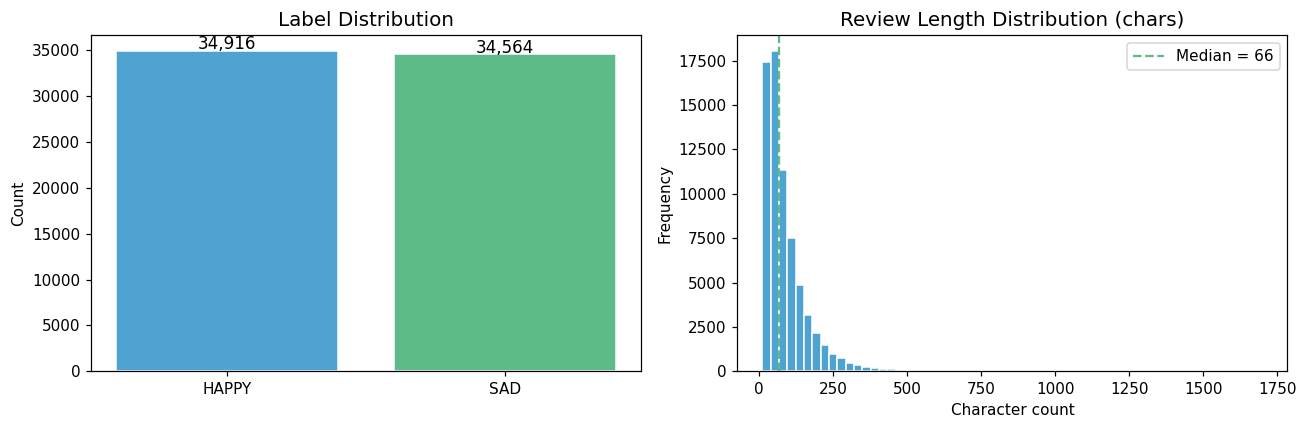


Length stats (chars):
count    69480.0
mean        89.7
std         76.7
min         11.0
25%         39.0
50%         66.0
75%        114.0
max       1700.0


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Label distribution
counts = df_raw['label'].value_counts()
axes[0].bar(counts.index, counts.values, color=['#4FA3D1', '#5DBB8A'], edgecolor='white')
axes[0].set_title('Label Distribution', fontsize=13)
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 200, f'{v:,}', ha='center', fontsize=11)

# Review length distribution (character count)
df_raw['char_len'] = df_raw['comment'].str.len()
axes[1].hist(df_raw['char_len'], bins=60, color='#4FA3D1', edgecolor='white')
axes[1].set_title('Review Length Distribution (chars)', fontsize=13)
axes[1].set_xlabel('Character count')
axes[1].set_ylabel('Frequency')
axes[1].axvline(df_raw['char_len'].median(), color='#5DBB8A', linestyle='--', label=f'Median = {df_raw["char_len"].median():.0f}')
axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'eda_distribution.png'), dpi=120, bbox_inches='tight')
plt.show()

print(f"\nLength stats (chars):")
print(df_raw['char_len'].describe().round(1).to_string())

In [6]:
# Show 5 raw sample reviews
print("=== Sample raw reviews ===")
for i, row in df_raw.sample(5, random_state=1).iterrows():
    print(f"[{row['label']}] {row['comment']}")
    print()

=== Sample raw reviews ===
[SAD] کیفیت واقعا افت فاحشی داره حیف اون همه خاطره ما از پیتزا پرپروک

[SAD] برخورد پیک بسیار زشت و بی ادبانه بود.

[SAD] کیفیت خیلی بدددد بود - حجم غذا خیلی کم شده - واقعا متاسفم که برای همچین غذای بدرد نخوری پول دادم

[SAD] در توضیحات نوشته بودم فقط ژامبون مرغ محبت کنید بدین معنا که ژامبون گوشت نذارید، نه اینکه ساندویچ رو بدون هیچ مخلافاتی فقط با ژامبون گوشت و مرغ خالی ارسال کنید، غذا خوب بود و ممنونم ازتون که به بقیه نکات توجه کرده بودید!

[HAPPY] ممنون از رفتار بسیار مناسب پیک



## 3. Text Preprocessing

All cleaning logic lives in `src/preprocessing.py`. Key **sentiment-aware** decisions:

- **Negation is tagged, not deleted.** `غذا خوب نبود` → `غذا NEG_خوب نبود`. The `NEG_`
  prefix lets the model learn that "good" under negation means the opposite. This is the
  single highest-impact feature for sentiment (Pang & Lee, 2002).
- **Emojis are mapped, not stripped.** `😍`→`EMO_POS`, `🤮`→`EMO_NEG`. In food-delivery
  reviews emojis carry loud polarity, so we keep them as explicit tokens.
- **Stopword removal is OFF by default.** Hazm's stoplist contains negators and
  intensifiers (خیلی, هیچ, نه) that flip or amplify sentiment; for TF-IDF the IDF term
  already down-weights frequent words. Toggle it on only for an ablation.
- **URL removal runs before Hazm normalization** — the normalizer strips `:` and `/`.
- **Repeat-char collapse to 1** — خوووب به خوب, so the lemmatizer sees a valid root.
- **Lemmatization** returns `past_stem#present_stem` for verbs; we take `[0]` (past stem)
  as the canonical root. `EMO_`/`NEG_`/`EMPH_` tokens are never lemmatized.

In [7]:
from preprocessing import clean_text, preprocess_dataframe, show_examples

# ---------------------------------------------------------------------------
# Ablation switches. The defaults below are tuned for SENTIMENT accuracy, not
# generic text cleaning. Flip any of these to run an ablation, then re-run the
# notebook end-to-end and compare downstream F1 in Phase 3/5.
#
#   handle_negation : NEG_ tag tokens after a negator (Pang & Lee). Sentiment's
#                     single most important feature — keep ON.
#   map_emoji       : map sentiment emojis to EMO_POS / EMO_NEG tokens.
#   lemmatize       : Hazm lemmatization (special EMO_/NEG_ tokens untouched).
#   remove_stopwords: OFF by default — Hazm's stoplist contains negators and
#                     intensifiers that flip sentiment; IDF already down-weights
#                     frequent words. Turn ON only for an ablation.
#   mark_elongation : emit EMPH_ marker for elongated words (خیلیییی). OFF.
# ---------------------------------------------------------------------------
CLEAN_KWARGS = dict(
    handle_negation=True,
    map_emoji=True,
    lemmatize=True,
    remove_stopwords=False,
    mark_elongation=False,
    neg_window=3,
    min_token_len=2,
)

print('Preprocessing pipeline imported.')
print('Active cleaning config:')
for k, v in CLEAN_KWARGS.items():
    print(f'  {k:18s}= {v}')

Preprocessing pipeline imported.
Active cleaning config:
  handle_negation   = True
  map_emoji         = True
  lemmatize         = True
  remove_stopwords  = False
  mark_elongation   = False
  neg_window        = 3
  min_token_len     = 2


In [8]:
# This takes ~1-2 minutes on 70k rows (Hazm tokenizer + lemmatizer per row).
# preprocess_dataframe PRESERVES the raw `comment` column (needed for the
# ParsBERT phase and for human-readable prediction examples in the report).
print('Running preprocessing... (may take 1-2 min)')
df_clean = preprocess_dataframe(
    df_raw, text_col='comment', label_col='label', **CLEAN_KWARGS
)
print(f'Done. Rows after cleaning: {len(df_clean):,}')
print('Columns:', df_clean.columns.tolist())
df_clean.head(3)

Running preprocessing... (may take 1-2 min)
[preprocessing] Dropped 1 rows with empty text after cleaning.
Done. Rows after cleaning: 69,479
Columns: ['comment', 'label', 'cleaned']


,comment,label,cleaned
0,واقعا حیف وقت که بنویسم سرویس دهیتون شده افتضاح,SAD,واقعا حیف وقت که نوشت سرویس دهیتون شده افتضاح
1,قرار بود ۱ ساعته برسه ولی نیم ساعت زودتر از موقع رسید، شما ببین چقدرررررررررررر پلاک خفنههههه، من سالهاست مشتریشونم ...,HAPPY,قرار بود ساعته برسه ولی نیم ساعت زودتر از موقع رسید شما دید چقدر پلاک خفنهه من سالهاست مشتریشونم سالهاست مزه بهشت می...
2,قیمت این مدل اصلا با کیفیتش سازگاری نداره، فقط ظاهر فریبنده داره، پرش میکنن کالباس و قارچ,SAD,قیمت این مدل اصلا با کیفیت سازگاری نداره فقط ظاهر فریبنده داره پرش میکنن کالباس قارچ


## 4. Before / After Examples

In [9]:
# Pick representative examples: positive, negative, with emojis, with repeated chars, with URL
manual_examples = [
    'سلام خیلی خوووووب بود! غذا عالیییی بود ⭐⭐⭐',
    'بدترین تجربه زندگیم بود. اصلا توصیه نمیکنم به هیچ کس',
    'غذا وقتی رسید سرد بوووووود. افتضاح',
    'https://snappfood.ir عالی عالی عالی پیتزا خوشمزه',
    'كيفيت پايين ، قيمت بالا ، تحويل دير',   # Arabic chars (ك ي) before normalization
]

print(f"{'BEFORE':<55} {'AFTER'}")
print('-' * 100)
for raw in manual_examples:
    cleaned = clean_text(raw)
    print(f"{raw[:52]:<55} {cleaned}")
    print()

BEFORE                                                  AFTER
----------------------------------------------------------------------------------------------------
سلام خیلی خوووووب بود! غذا عالیییی بود ⭐⭐⭐              سلام خیلی خوب بود غذا عالی بود

بدترین تجربه زندگیم بود. اصلا توصیه نمیکنم به هیچ کس    بدترین تجربه زندگیم بود اصلا توصیه کرد به هیچ‌کس

غذا وقتی رسید سرد بوووووود. افتضاح                      غذا وقتی رسید سرد بوود افتضاح

https://snappfood.ir عالی عالی عالی پیتزا خوشمزه        عالی عالی عالی پیتزا خوشمزه

كيفيت پايين ، قيمت بالا ، تحويل دير                     کیفیت پایین قیمت بالا تحویل دیر



In [10]:
# Also show 10 random examples from the actual dataset
sample_idx = df_clean.sample(10, random_state=42).index

comparison = pd.DataFrame({
    'Before (raw)':  df_raw.loc[sample_idx, 'comment'].str[:80].values,
    'After (clean)': df_clean.loc[sample_idx, 'cleaned'].str[:80].values,
    'Label':         df_clean.loc[sample_idx, 'label'].values,
})
comparison

,Before (raw),After (clean),Label
0,یه چیز دیگه ارسال کردن بدون اجازه,استریپس‌ها تازه بود NEG_و NEG_انگار NEG_روز قبل درست شد,HAPPY
1,کاملأ روی چیز کیک‌ها سوخته بود و به خاطر این مشکل طعمش هم خیلی بد شده بود,بهتره بتون ران یا سینه رو خودمون انتخاب کرد,HAPPY
2,نوار بهداشتی که سفارش دادم با محصول ارسالی مدلش متفاوته … الان این محصول غیر قاب,غذا بد بود حالم خیلی بده دل دردو دل‌پیچه معلوم نیست NEG_چی NEG_توش NEG_ریختن افت,SAD
3,با سلام سابق بر این بسته بندی از کیفیت بهتری برخوردار بود. ولی در حال حاضر ایراد,جوس برگر چیکن ماشروم برگر خوب بود ولی سیب‌زمینی اصلا کیفیت قبل را داشت NEG_و NEG,HAPPY
4,غذای سوخته و سرد ارسال کردن و کیفیت فوق العاده پایین,سس مثل همیشه فراموش‌شده بود اما برگر مثل همیشه عالی,HAPPY
5,خیلی زود رسید و ممنون م ازشون,سلام نون داغ تازه خوبی بود ولی از ساعتی که انتخاب کرد زودتر آورد ضمنا نایلون نون,HAPPY
6,خیلی داغ به دستم رسید و خوشمزه بود ممنون.,مواد پیتزا بسیار کم بود با اینکه قیمت اصلا پایین نیست ولی کلا طعم پیتزا خوب تازه,HAPPY
7,قارچ سوخاری خوب بود، اما قارچ برگر خیلی بی مزه بود,کیفیت زیاد خوب بود,HAPPY
8,مرغی که واسه ما آوردن بو میداد انگار که مونده بود!,خیلی خوش‌مزه بود وعال ممنون,HAPPY
9,خیلی دلپذیر و بدون نقص. خوشمزه بود واقعا,همه چی خوب بود ولی اگه تخفیف داشت اصلا خرید کرد چون گرونه برام,HAPPY


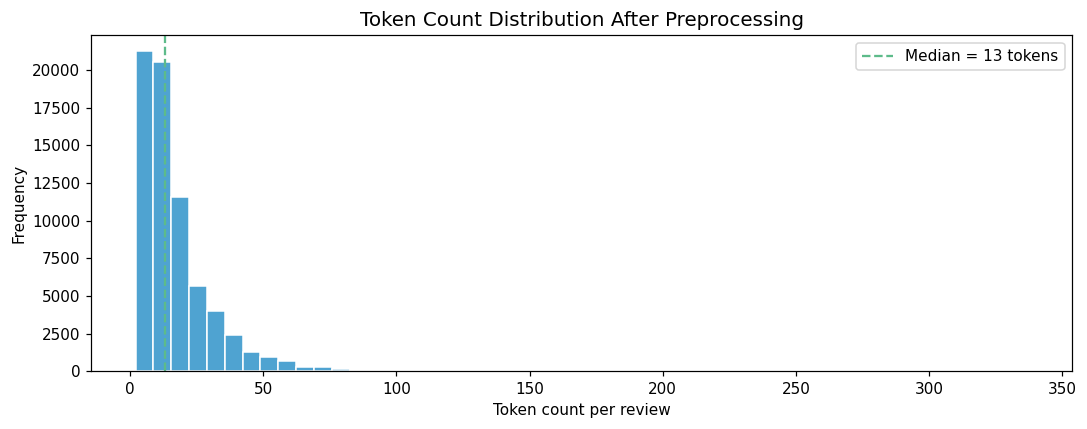

count    69479.0
mean        17.0
std         14.5
min          2.0
25%          8.0
50%         13.0
75%         22.0
max        337.0
Name: token_count, dtype: float64


In [11]:
# Token count distribution after cleaning
df_clean['token_count'] = df_clean['cleaned'].str.split().str.len()

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(df_clean['token_count'], bins=50, color='#4FA3D1', edgecolor='white')
ax.axvline(df_clean['token_count'].median(), color='#5DBB8A', linestyle='--',
           label=f'Median = {df_clean["token_count"].median():.0f} tokens')
ax.set_title('Token Count Distribution After Preprocessing', fontsize=13)
ax.set_xlabel('Token count per review')
ax.set_ylabel('Frequency')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'token_distribution.png'), dpi=120, bbox_inches='tight')
plt.show()

print(df_clean['token_count'].describe().round(1))

## 5. Train / Test Split

**80 / 20 split**, stratified on label to keep class balance identical in both sets.
`random_state=42` for reproducibility.

In [12]:
# Binary encode labels: HAPPY=1, SAD=0
label_map = {'HAPPY': 1, 'SAD': 0}
df_clean['label_enc'] = df_clean['label'].map(label_map)

# Split the whole frame (not just the cleaned text) so the RAW `comment` column
# travels into train.csv / test.csv. ParsBERT (Phase 6) consumes raw text, and
# the report needs human-readable examples — both need the original comment.
train_df, test_df = train_test_split(
    df_clean[['comment', 'cleaned', 'label_enc']],
    test_size=0.20,
    random_state=42,
    stratify=df_clean['label_enc'],
)
train_df = train_df.reset_index(drop=True).rename(columns={'label_enc': 'label'})
test_df  = test_df.reset_index(drop=True).rename(columns={'label_enc': 'label'})

# Convenience arrays used by the cells below.
X_train, y_train = train_df['cleaned'].values, train_df['label'].values
X_test,  y_test  = test_df['cleaned'].values,  test_df['label'].values

print(f'Train size : {len(train_df):,}')
print(f'Test  size : {len(test_df):,}')
print(f'Train HAPPY: {y_train.sum():,} / SAD: {(y_train==0).sum():,}')
print(f'Test  HAPPY: {y_test.sum():,}  / SAD: {(y_test==0).sum():,}')

Train size : 55,583
Test  size : 13,896
Train HAPPY: 27,933 / SAD: 27,650
Test  HAPPY: 6,983  / SAD: 6,913


## 6. Save Processed Data

In [13]:
# Save train and test as CSV. Each row now carries:
#   comment  — raw Persian text  (for ParsBERT + readable report examples)
#   cleaned  — preprocessed tokens (for CountVectorizer / TF-IDF / Word2Vec)
#   label    — HAPPY=1, SAD=0
train_df[['comment', 'cleaned', 'label']].to_csv(
    os.path.join(DATA_PROC, 'train.csv'), index=False, encoding='utf-8')
test_df[['comment', 'cleaned', 'label']].to_csv(
    os.path.join(DATA_PROC, 'test.csv'),  index=False, encoding='utf-8')

# Save label arrays as npy for fast loading in later notebooks
np.save(os.path.join(DATA_PROC, 'y_train.npy'), y_train)
np.save(os.path.join(DATA_PROC, 'y_test.npy'),  y_test)

print('Saved:')
print(f'  data/processed/train.csv  ({len(train_df):,} rows, cols: comment, cleaned, label)')
print(f'  data/processed/test.csv   ({len(test_df):,} rows, cols: comment, cleaned, label)')
print(f'  data/processed/y_train.npy')
print(f'  data/processed/y_test.npy')

Saved:
  data/processed/train.csv  (55,583 rows, cols: comment, cleaned, label)
  data/processed/test.csv   (13,896 rows, cols: comment, cleaned, label)
  data/processed/y_train.npy
  data/processed/y_test.npy


## 7. Summary

| Step | Detail |
|---|---|
| Raw dataset | 70,000 reviews (HAPPY / SAD) |
| After cleaning | see output above |
| Train split | 80% — stratified |
| Test split | 20% — stratified |
| Label encoding | HAPPY=1, SAD=0 |
| Saved files | `train.csv`, `test.csv`, `y_train.npy`, `y_test.npy` |

**Next:** Phase 2 — Vectorization (`02_vectorization.ipynb`)